# 1. Point clouds and I/O

`sylva.PointCloud` is an `(N, 3)` float64 array plus named per-point attributes.
It is what readers return and what almost every function takes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})

A synthetic plot to work with: sloped terrain and four trees. `classification` and `tree_id` are the ground truth.

In [2]:
cloud = synthetic.forest()
print(cloud)
lo, hi = cloud.bounds
print("extent:", np.round(hi - lo, 2), "m")
{k: (v.dtype, v.min(), v.max()) for k, v in cloud.attrs.items()}

PointCloud(n=314,795, attrs=['classification', 'tree_id'])
extent: [28.   28.   18.47] m


{'classification': (dtype('uint8'), np.uint8(2), np.uint8(5)),
 'tree_id': (dtype('int32'), np.int32(0), np.int32(4))}

Indexing with a mask, indices or a slice keeps the attributes aligned. `with_attrs` returns a copy with extra columns.

In [3]:
wood = cloud[cloud.attrs["classification"] == 5]
cloud = cloud.with_attrs(range=np.linalg.norm(cloud.xyz - [10, 10, 1.5], axis=1).astype(np.float32))
print(wood, cloud, sep="\n")

PointCloud(n=202,795, attrs=['classification', 'tree_id'])
PointCloud(n=314,795, attrs=['classification', 'range', 'tree_id'])


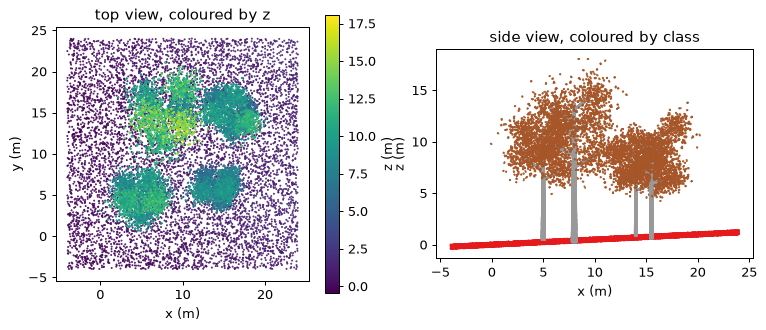

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
s = ax[0].scatter(cloud.x[::5], cloud.y[::5], c=cloud.z[::5], s=0.3, cmap="viridis")
ax[0].set(title="top view, coloured by z", xlabel="x (m)", ylabel="y (m)", aspect="equal")
fig.colorbar(s, ax=ax[0], label="z (m)")
ax[1].scatter(cloud.x[::5], cloud.z[::5], c=cloud.attrs["classification"][::5], s=0.3, cmap="Set1")
ax[1].set(title="side view, coloured by class", xlabel="x (m)", ylabel="z (m)", aspect="equal");

## Reading and writing

`sylva.read` / `sylva.write` pick the format from the extension: LAS/LAZ (extra
attributes become typed extra-bytes dimensions), PLY, and delimited text.
RIEGL `.rxp` needs RiVLib, see `sylva.io.read_rxp`.

In [5]:
import tempfile, pathlib
tmp = pathlib.Path(tempfile.mkdtemp())
for name in ("plot.laz", "plot.ply", "plot.csv"):
    sylva.write(cloud, tmp / name)
    back = sylva.read(tmp / name)
    print(f"{name:9s} {(tmp / name).stat().st_size / 1e6:6.2f} MB  {len(back):,} points  attrs: {sorted(back.attrs)}")

plot.laz    2.24 MB  314,795 points  attrs: ['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'range', 'return_number', 'scan_angle', 'tree_id', 'user_data']
plot.ply   10.39 MB  314,795 points  attrs: ['classification', 'range', 'tree_id']


plot.csv   14.03 MB  314,795 points  attrs: ['classification', 'range', 'tree_id']


In [6]:
laz = sylva.read(tmp / "plot.laz")
print("max coordinate error after LAZ (1 mm scale):", np.abs(laz.xyz - cloud.xyz).max())
print("range attribute dtype preserved:", laz.attrs["range"].dtype)

max coordinate error after LAZ (1 mm scale): 0.0004999993010188497
range attribute dtype preserved: float32


Plain arrays come in through `PointCloud.from_array`, naming the columns after x, y, z.

In [7]:
arr = np.column_stack([cloud.xyz, cloud.attrs["classification"]])
sylva.PointCloud.from_array(arr, names={3: "classification"})

PointCloud(n=314,795, attrs=['classification'])